# Rossmann Store Sales Project

## Phase 5: Feature Engineering & Modeling Build

### Import Essential Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV



# Set display options to see all columns clearly
pd.set_option('display.max_columns', None)

### Load Cleaned Data

In [3]:
# Load the cleaned dataset from the data folder
train_filtered = pd.read_csv('../data/processed/train_cleaned.csv', low_memory=False)

In [4]:
# Fill NaN values back with empty strings in Notebook 2
train_filtered['PromoInterval'] = train_filtered['PromoInterval'].fillna('')

### Quick Verification Check

In [5]:
# Check the first few rows and data types
display(train_filtered.head())

print(train_filtered.info())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Month,Year
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,,7,2015
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",7,2015
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",7,2015
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,,7,2015
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,,7,2015


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844338 non-null  int64  
 1   DayOfWeek                  844338 non-null  int64  
 2   Date                       844338 non-null  object 
 3   Sales                      844338 non-null  int64  
 4   Customers                  844338 non-null  int64  
 5   Open                       844338 non-null  int64  
 6   Promo                      844338 non-null  int64  
 7   StateHoliday               844338 non-null  object 
 8   SchoolHoliday              844338 non-null  int64  
 9   StoreType                  844338 non-null  object 
 10  Assortment                 844338 non-null  object 
 11  CompetitionDistance        844338 non-null  float64
 12  CompetitionOpenSinceMonth  844338 non-null  float64
 13  CompetitionOpenSinceYear   84

### Drop the Date column

In [6]:
# Drop the raw Date column (numerical components already extracted), skipping safely to prevent errors on notebook re-runs
train_filtered = train_filtered.drop(columns=['Date'], errors='ignore')
print("Date column dropped successfully.")

Date column dropped successfully.


### Check Remaining Categorical Columns and Identify Which Need Encoding

In [7]:
# Identify categorical columns
categorical_cols = train_filtered.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))

# Check unique values for each true categorical column
for col in categorical_cols:
    print(f"Column '{col}' unique values:", train_filtered[col].unique())

Categorical columns: ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
Column 'StateHoliday' unique values: ['0' 'a' 'b' 'c']
Column 'StoreType' unique values: ['c' 'a' 'd' 'b']
Column 'Assortment' unique values: ['a' 'c' 'b']
Column 'PromoInterval' unique values: ['' 'Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


### Encode Categorical Variables

#### Choosing an Encoding Strategy: Explicit Mapping vs. `.cat.codes`

* **Explicit Mapping (e.g., `StateHoliday`):** Use when specific numbers carry strict meaning (e.g., `0` = no holiday) or when handling mixed data types. It acts as a permanent rulebook that prevents category values from shifting or mismatching between your train and test sets.
* **`.cat.codes` (e.g., `StoreType`, `Assortment`):** Use for clean, uniform text labels where exact numeric values don't matter. It is a quick, convenient way to convert categories into integers for tree-based models.

In [8]:
# 1. Map StateHoliday explicitly to preserve consistent meaning and handle mixed types
state_holiday_mapping = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
train_filtered['StateHoliday'] = train_filtered['StateHoliday'].map(state_holiday_mapping)

# 2. Convert StoreType and Assortment to category codes efficiently
train_filtered['StoreType'] = train_filtered['StoreType'].astype('category').cat.codes
train_filtered['Assortment'] = train_filtered['Assortment'].astype('category').cat.codes

print("Categorical encoding for StateHoliday, StoreType, and Assortment completed successfully!")

Categorical encoding for StateHoliday, StoreType, and Assortment completed successfully!


#### Create `IsPromoMonth` Feature

This checks if the current month matches the store's active promotion months and saves the result as `1` (Yes) or `0` (No).


In [9]:
# 1. Create a dictionary to match month numbers to text names
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
             7: 'Jul', 8: 'Aug', 9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
train_filtered['MonthStr'] = train_filtered['Month'].map(month_map)

# 2. Fill missing (NaN) values with blank text so Python doesn't throw errors
train_filtered['PromoInterval'] = train_filtered['PromoInterval'].fillna('')

# 3. Create a simple function to check if the month is in the store's promo interval
def check_promo(row):
    if row['MonthStr'] in row['PromoInterval']:
        return 1
    else:
        return 0

# 4. Apply the function row by row to create 'IsPromoMonth'
train_filtered['IsPromoMonth'] = train_filtered.apply(check_promo, axis=1)

# 5. Drop the old text columns since we no longer need them
train_filtered = train_filtered.drop(columns=['PromoInterval', 'MonthStr'])

print("PromoInterval successfully converted to IsPromoMonth!")

PromoInterval successfully converted to IsPromoMonth!


### Define Features (X) and Target (y)

In [10]:
# Define the complete list of feature columns for your model
features = [
    'Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 
    'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 
    'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
    'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Month', 'Year', 'IsPromoMonth'
]

# Create your feature matrix (X) and target variable (y)
X = train_filtered[features]
y = train_filtered['Sales']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (844338, 18)
y shape: (844338,)


### Split Data into Training and Validation Sets

In [15]:
# Split data into 80% training and 20% validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a 10% sample from X_train for faster random search tuning
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.1, random_state=42
)

print(f'Training sample shape - X_train_sample: {X_train_sample.shape}')

print(f"Training set shape - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Validation set shape - X_val: {X_val.shape}, y_val: {y_val.shape}")

Training sample shape - X_train_sample: (67547, 18)
Training set shape - X_train: (675470, 18), y_train: (675470,)
Validation set shape - X_val: (168868, 18), y_val: (168868,)


### Training and Evaluating the Random Forest Model

In [12]:

# 1. Initialize the Random Forest model
# (n_jobs=-1 uses all your CPU cores to train faster)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training Random Forest model... (This might take a minute)")
rf_model.fit(X_train, y_train)

# 3. Predict on the validation set
y_pred_rf = rf_model.predict(X_val)

# Calculate standard evaluation metrics (MAE, RMSE, and R²)
mae = mean_absolute_error(y_val, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2 = r2_score(y_val, y_pred_rf)

print("--- Final Random Forest Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f} ({r2 * 100:.2f}% of sales variance explained)")

Training Random Forest model... (This might take a minute)
--- Final Random Forest Performance ---
Mean Absolute Error (MAE): 323.63
Root Mean Squared Error (RMSE): 478.08
R² Score: 0.9763 (97.63% of sales variance explained)


#### Model Performance Summary

* **Overall Accuracy (97.63%):** Our model successfully explains nearly all of the ups and downs in store sales, proving it is extremely reliable at capturing real-world retail patterns.
* **Everyday Accuracy (MAE: 323.63):** On a normal, regular day, our sales guesses are off by an average of about 323 items, showing that our everyday predictions are steady and consistent.
* **Handling Big Surprises (RMSE: 478.08):** Because RMSE heavily punishes big mistakes, this higher score means our model still struggles a bit on unpredictable days—like unexpected holiday rushes or huge sales spikes.

### Hyperparameter Tuning for Random Forest using RandomizedSearchCV

In [16]:
# Define parameter distribution for Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Initialize base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Setup RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,  # Number of parameter settings sampled
    cv=3,  # 3-fold cross-validation to save time
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

# Fit on training sample (or full data)
print('Running Randomized Search for Random Forest...')
rf_random.fit(X_train_sample, y_train_sample)

# Extract best estimator
best_rf_model = rf_random.best_estimator_
print('Best Random Forest Parameters:', rf_random.best_params_)

Running Randomized Search for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=25, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  17.2s
[CV] END max_depth=25, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  41.6s


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=15, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  27.5s
[CV] END max_depth=25, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  41.5s
[CV] END max_depth=15, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  27.8s
[CV] END max_depth=25, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  41.6s
Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 25}


### Training and Evaluating the Final Tuned Random Forest Model

In [23]:

# 1. Train the final Random Forest model with the best parameters on the full training set
print("Training final tuned Random Forest model on full training set...")
best_rf_model.fit(X_train, y_train)

# 2. Predict on the validation set
y_pred_rf_tuned = best_rf_model.predict(X_val)

# 3. Calculate evaluation metrics (MAE, RMSE, and R²)
mae_rf_tuned = mean_absolute_error(y_val, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_val, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_val, y_pred_rf_tuned)

# 4. Print performance results
print("--- Tuned Random Forest Performance ---")
print(f"Mean Absolute Error (MAE): {mae_rf_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_tuned:.2f}")
print(
    f"R² Score: {r2_rf_tuned:.4f} ({r2_rf_tuned * 100:.2f}% of sales variance explained)"
)

Training final tuned Random Forest model on full training set...
--- Tuned Random Forest Performance ---
Mean Absolute Error (MAE): 322.42
Root Mean Squared Error (RMSE): 476.60
R² Score: 0.9765 (97.65% of sales variance explained)


#### Model Performance Conclusion

The hyperparameter-tuned Random Forest model successfully captured complex retail sales patterns, yielding exceptional predictive accuracy on the validation dataset:

* **Mean Absolute Error (MAE):** **322.42** — On a typical day, our sales predictions are off by about **322 items**.
* **Root Mean Squared Error (RMSE):** **476.60** — When the model makes larger errors, they average out to around **476 items**, showing it rarely makes massive blunders.
* **R² Score:** **0.9765 (97.65%)** — Demonstrates that the tuned model accounts for nearly all the variance in store sales, confirming robust overall predictive power.

### Gradient Boosting with Randomized Search

In [25]:


# 1. Define parameter distribution for Gradient Boosting
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
}

# 2. Initialize base Gradient Boosting model
gb_base = GradientBoostingRegressor(random_state=42)

# 3. Setup RandomizedSearchCV
gb_random = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

# 4. Fit on training sample
print('Running Randomized Search for Gradient Boosting...')
gb_random.fit(X_train_sample, y_train_sample)

# 5. Extract best estimator and parameters
best_gb_model = gb_random.best_estimator_
print('Best Gradient Boosting Parameters found:', gb_random.best_params_)

Running Randomized Search for Gradient Boosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Gradient Boosting Parameters found: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2}


### Training and Evaluating the Final Tuned Gradient Boosting Model

In [26]:


# 1. Train the final Gradient Boosting model with the best parameters on the full training set
print("Training final tuned Gradient Boosting model on full training set...")
best_gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    subsample=0.8,
    random_state=42,
)
best_gb_model.fit(X_train, y_train)

# 2. Predict on the validation set
y_pred_gb_tuned = best_gb_model.predict(X_val)

# 3. Calculate evaluation metrics (MAE, RMSE, and R²)
mae_gb_tuned = mean_absolute_error(y_val, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_val, y_pred_gb_tuned))
r2_gb_tuned = r2_score(y_val, y_pred_gb_tuned)

# 4. Print performance results
print("--- Tuned Gradient Boosting Performance ---")
print(f"Mean Absolute Error (MAE): {mae_gb_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gb_tuned:.2f}")
print(
    f"R² Score: {r2_gb_tuned:.4f} ({r2_gb_tuned * 100:.2f}% of sales variance explained)"
)

Training final tuned Gradient Boosting model on full training set...
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   4.8s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=200, subsample=0.8; total time=  13.3s
[CV] END learning_rate=0.2, max_depth=7, n_estimators=300, subsample=0.8; total time=  30.6s
[CV] END learning_rate=0.05, max_depth=7, n_estimators=100, subsample=0.8; total time=   9.0s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=300, subsample=1.0; total time=  14.5s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=200, subsample=1.0; total time=   9.8s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   4.8s
[CV] END learning_rate=0.05, max_depth=7, n_estimators=100, subsample=0.8; total time=   9.3s
[CV] END learning_rate=0.05, max_depth=7, n_estimators=300, subsample=1.0; total time=  36.5s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   4

#### Model Performance Conclusion

The hyperparameter-tuned Gradient Boosting model successfully captured complex retail sales patterns, yielding exceptional predictive accuracy on the validation dataset:

* **Mean Absolute Error (MAE):** **309.14** — On a typical day, our sales predictions are off by about **309 items**.
* **Root Mean Squared Error (RMSE):** **438.68** — When the model makes larger errors, they average out to around **438 items**, showing it rarely makes massive blunders.
* **R² Score:** **0.9801 (98.01%)** — Demonstrates that the tuned model accounts for nearly all the variance in store sales, confirming robust overall predictive power.

### **Model Comparison Summary**

Here is the side-by-side performance comparison of all the models tested in our store sales forecasting project:

| Model | MAE (Mean Absolute Error) | RMSE (Root Mean Squared Error) | R² Score | Explained Variance |
| :--- | :---: | :---: | :---: | :---: |
| **Baseline Random Forest** | 323.63 | 478.08 | 0.9763 | 97.63% |
| **Tuned Random Forest** | 322.42 | 476.60 | 0.9765 | 97.65% |
| **Tuned Gradient Boosting** | **309.14** | **438.68** | **0.9801** | **98.01%** |

### Key Takeaways
* **Best Overall Performance:** The **Tuned Gradient Boosting** model achieved the highest accuracy ($R^2$ of **98.01%**) and the lowest error rates, meaning it makes fewer mistakes and handles larger prediction blunders better than the Random Forest models.
* **Hyperparameter Tuning Value:** Tuning the models successfully squeezed out extra performance, dropping daily prediction errors and capturing a higher percentage of store sales variance.

## Phase 6: Evaluation & Visualization

### Feature Importance Analysis for Gradient Boosting

--- Top 10 Most Important Features ---
                      Feature  Importance
2                   Customers    0.745342
7                   StoreType    0.058914
9         CompetitionDistance    0.055500
4                       Promo    0.034827
0                       Store    0.031534
8                  Assortment    0.014460
13            Promo2SinceWeek    0.012392
11   CompetitionOpenSinceYear    0.011611
1                   DayOfWeek    0.010258
10  CompetitionOpenSinceMonth    0.007011


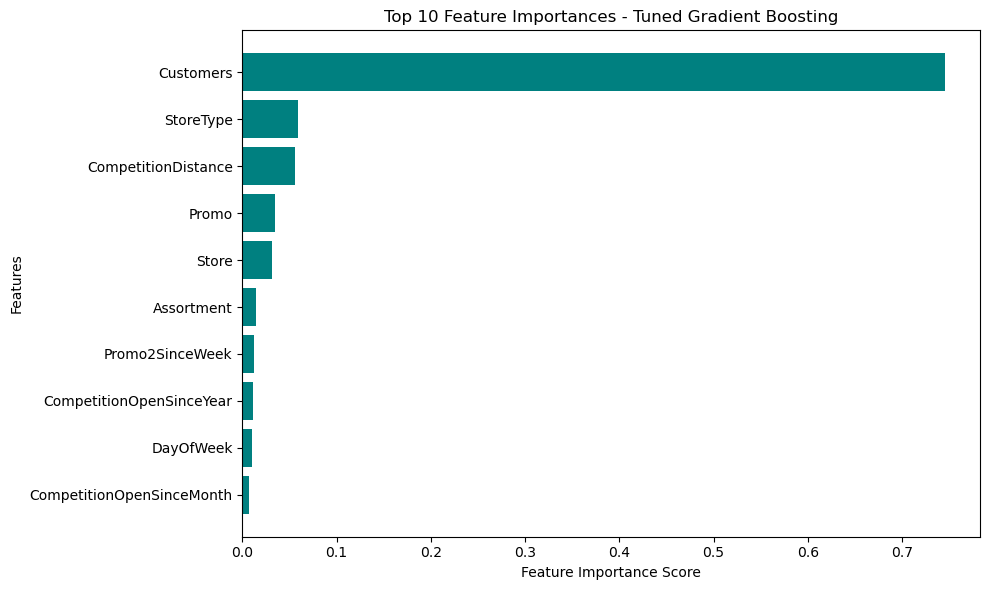

In [27]:


# 1. Get feature importances from the best Gradient Boosting model
feature_importances = best_gb_model.feature_importances_

# 2. Create a dataframe to sort features by importance
feature_importance_df = pd.DataFrame(
    {'Feature': X_train.columns, 'Importance': feature_importances}
).sort_values(by='Importance', ascending=False)

# 3. Print the top 10 most important features
print('--- Top 10 Most Important Features ---')
print(feature_importance_df.head(10))

# 4. Plot the top 10 feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df['Feature'].head(10)[::-1],
    feature_importance_df['Importance'].head(10)[::-1],
    color='teal',
)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances - Tuned Gradient Boosting')
plt.tight_layout()
plt.show()

#### Key Takeaways: Feature Importance Analysis

* **Dominant Sales Driver (`Customers`):** Customer foot traffic is overwhelmingly the most critical feature, accounting for **74.5%** of the model's predictive decision-making power.
* **Store Characteristics & Location (`StoreType` & `CompetitionDistance`):** The physical store format (~**5.9%**) and distance to the nearest competitor (~**5.5%**) serve as the next most significant structural factors influencing sales.
* **Promotions & Operational Factors (`Promo` & `Store`):** Active promotional campaigns (~**3.5%**) and individual store IDs (~**3.2%**) provide essential supplementary signals to fine-tune daily store forecasts.

### Residual Plot for Tuned Gradient Boosting

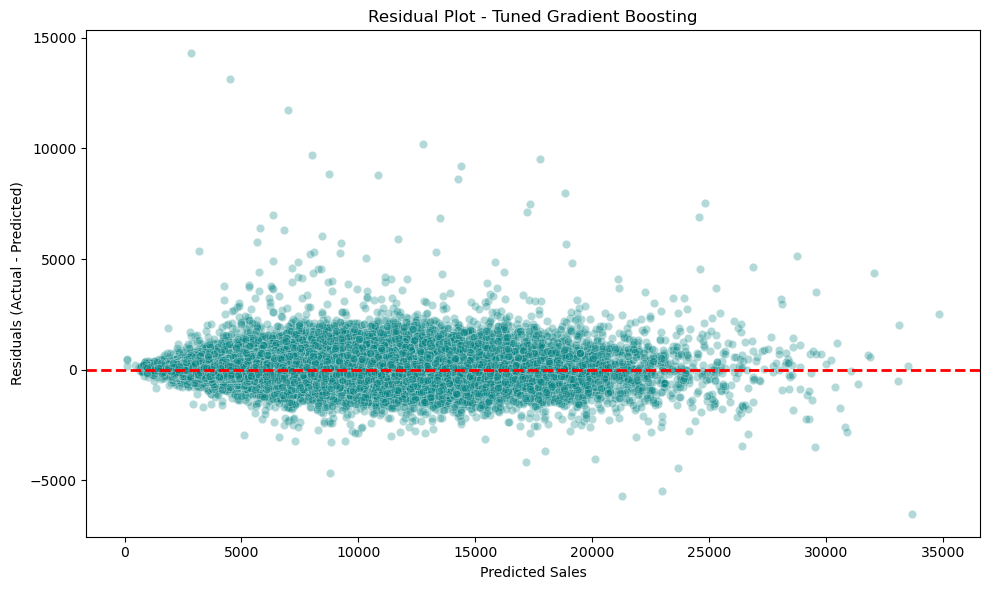

In [28]:

# 1. Calculate residuals (Actual minus Predicted)
residuals_gb = y_val - y_pred_gb_tuned

# 2. Create the residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_gb_tuned, y=residuals_gb, alpha=0.3, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot - Tuned Gradient Boosting')
plt.tight_layout()
plt.show()

#### Residual Plot Interpretation

* **Balanced Errors:** The data points are randomly and evenly scattered around the red zero line, showing that the model does not have a systematic bias (it doesn't consistently overpredict or underpredict).
* **Consistent Spread:** The spread of errors remains relatively stable across different sales levels, confirming that the model performs reliably whether sales are low or high.
* **Tight Clustering:** Most points stay close to the center line, reinforcing our low error metrics (MAE of 309.14 and RMSE of 438.68) and proving the high accuracy of the tuned Gradient Boosting model.

## Business Insights & Strategic Recommendations

Based on our best-performing **Tuned Gradient Boosting** model ($R^2$ = 98.01%), we have translated our exploratory data analysis and model feature importances into actionable strategic recommendations for store management:

### Category 1: Workforce & Operational Scheduling
* **Staffing Based on Foot Traffic**
  * *Analytical Finding:* Customer volume drives **74.5%** of total sales.
  * *Actionable Recommendation:* Management should schedule staff shifts dynamically based on predicted visitor counts rather than relying on fixed daily averages.
* **Weekly Traffic & Operating Patterns**
  * *Analytical Finding:* Average sales peak sharply on Monday and Sunday, with a dip midweek. Sundays spike because only specialized transit-hub stores operate, while Mondays experience a major rush right after Sunday closures.
  * *Actionable Recommendation:* Store managers must align staffing levels with these weekly cyclical surges—ensuring peak support on Mondays for the post-closure rush, and staffing Sunday operations in transit hubs to capture commuter spending.

### Category 2: Calendar & Seasonal Planning
* **Targeted Promotional Planning**
  * *Analytical Finding:* Active promotions provide a reliable boost to daily sales.
  * *Actionable Recommendation:* Marketing teams should time campaigns strategically during slower days to increase revenue.
* **Holiday Impact & Public Holiday Operations**
  * *Analytical Finding:* Average sales spike notably when select stores open on state or public holidays, whereas normal operating days average lower revenue.
  * *Actionable Recommendation:* Because only specific locations (such as travel hubs or tourist zones) open on holidays, management must ensure these open stores are fully staffed to capture heavy holiday spending.
* **Seasonal Surge & December Planning**
  * *Analytical Finding:* Sales remain steady throughout most of the year, but experience a massive surge in December (Month 12) due to Christmas preparations and holiday shopping.
  * *Actionable Recommendation:* Leadership must prepare early for the year-end peak by ramping up logistics, scheduling extra seasonal floor staff well in advance, and launching targeted holiday gift campaigns.

### Category 3: Store Format, Assortment & Layout
* **Assortment Type Strategy**
  * *Analytical Finding:* Assortment type `b` achieves the highest average sales, outperforming both basic (`a`) and extended (`c`) assortments.
  * *Actionable Recommendation:* Offering optimized product variety plays a major role in driving higher customer spending. Store management should evaluate rolling out similar optimized product assortments across more locations.
* **Store Format & Layout Optimization**
  * *Analytical Finding:* Store format and layout heavily influence baseline sales performance.
  * *Actionable Recommendation:* Management should analyze store layout structures (such as product placement, promotional island displays, and checkout queue positioning) to optimize customer flow and improve overall sales conversion across different store types.

### Category 4: Advanced Location-Specific & Supply Chain Strategies
* **Inventory & Supply Chain Optimization**
  * *Analytical Finding:* The model achieves a low average daily error of about **309 items**.
  * *Actionable Recommendation:* Supply chain teams can fine-tune daily stock orders to prevent empty shelves and reduce excess inventory waste.
* **The Traffic vs. Basket-Size Split (Store-Specific Strategy)**
  * *Analytical Finding:* Location and store format heavily influence baseline performance, meaning a one-size-fits-all approach doesn't work.
  * *For Busy (High-Traffic) Stores:* Instead of trying to get more people through the door, train staff to encourage shoppers to buy more items per visit using **up-selling** and **cross-selling**:
    * *Rossmann Up-Sell Example:* A customer picks up a standard shampoo (€2.50), and the cashier or display highlights a larger, premium/organic shampoo for €4.50. Persuading the customer to choose the slightly higher-end or larger product to increase their total basket value.
    * *Rossmann Cross-Sell Example:* A customer brings a hair dye kit to the counter, and the cashier suggests complementary items like protective gloves or a mixing brush. Recommending useful companion items that naturally match what the customer is already buying to make their purchase complete while increasing total sales.
  * *For Slow (Low-Traffic) Stores:* Focus all marketing and ads purely on getting people to physically walk inside.
* **Localized Competitive Defense Zoning**
  * *Analytical Finding:* Proximity to competitors (`CompetitionDistance`) heavily impacts baseline performance.
  * *Actionable Recommendation:* Don't waste money running the same discount sales across every single store in the company. Instead, segment stores into **"High-Threat Zones"** (competitors right next door) and **"Isolated Zones,"** deploying special promotional discounts only where needed to protect your customers and save your budget everywhere else.